# Notebook 01 — One golden round of multi-objective Bayesian optimization

In Notebook 00 you built the vocabulary: dominance, the Pareto front, the
reference point, and hypervolume. Now we run **one real round** of batch Bayesian
optimization on the antibody library and watch the hypervolume move.

This is the **golden path**. Everything here is fully seeded, so *every team on
every laptop should get the exact same numbers* — the same chosen antibodies, the
same measured objectives, the same hypervolume before and after. The final cell
checks your results against the frozen reference for you.

The single round has five moves, the loop you will run six times in the
competition:

1. **fit** a surrogate model to what we have measured so far,
2. **score** unmeasured candidates with an *acquisition function*,
3. **pick** a batch of `BATCH_SIZE` antibodies,
4. **measure** them (query the oracle), and
5. **update** the data and recompute the hypervolume.

## 01.1 — Imports and seeding

We pin every random seed and work in double precision on the CPU. The constants
below are the lab-wide defaults; they are shown here as plain literals so you can
see exactly what drives the run.

In [1]:
import torch

from mobo_lab import config, data, metrics, plotting, seed
from mobo_lab.models import fit_surrogate_model
from mobo_lab.oracle import AntibodyOracle
from mobo_lab.optimize import optimize_continuous, optimize_discrete
from mobo_lab.pool import VHSequencePool
from mobo_lab.verification import verify_golden_path

# Make the run reproducible (seeds random / numpy / torch, sets dtype=double).
seed.set_all_seeds(config.SEED)

SEED = config.SEED
BATCH_SIZE = config.BATCH_SIZE          # antibodies tested per round
LATENT_DIM = config.LATENT_DIM          # design-space dimensionality
NUM_RESTARTS = config.NUM_RESTARTS      # acquisition-optimizer restarts
RAW_SAMPLES = config.RAW_SAMPLES        # acquisition-optimizer raw samples
MC_SAMPLES = config.MC_SAMPLES          # Monte-Carlo samples for the acquisition
REF_POINT = config.REF_POINT            # hypervolume reference point

print(f"SEED={SEED}  BATCH_SIZE={BATCH_SIZE}  LATENT_DIM={LATENT_DIM}")
print(f"NUM_RESTARTS={NUM_RESTARTS}  RAW_SAMPLES={RAW_SAMPLES}  MC_SAMPLES={MC_SAMPLES}")
print(f"REF_POINT={REF_POINT}")
print(f"device=cpu  dtype={torch.get_default_dtype()}")

SEED=123  BATCH_SIZE=4  LATENT_DIM=5
NUM_RESTARTS=10  RAW_SAMPLES=128  MC_SAMPLES=64
REF_POINT=[-0.05, -0.05]
device=cpu  dtype=torch.float64


## 01.2 — Load the candidate pool

The pool is the finite library of valid VH antibody sequences we can choose from.
Each sequence has a continuous **latent design vector** `x ∈ [0, 1]^LATENT_DIM`
(built in advance); the model and acquisition function reason over these vectors.

In [2]:
pool = VHSequencePool.from_files()
X_pool = pool.X

print(f"pool size: {len(pool)} sequences")
print(f"X_pool shape: {tuple(X_pool.shape)}")

assert X_pool.ndim == 2
assert X_pool.shape[1] == LATENT_DIM
assert X_pool.min() >= 0.0 and X_pool.max() <= 1.0

pool size: 2048 sequences
X_pool shape: (2048, 5)


## 01.3 — The shared initial design

Every team starts from the **same** `N_INITIAL` already-measured antibodies, so
the competition is fair. We read their IDs, look up their latent vectors, and
query the **oracle** for their (noisy) objective values.

The oracle is our stand-in for the wet lab. We build it with `allow_true=False`:
during the campaign you only ever see *noisy measurements*, never the hidden
ground truth.

In [3]:
initial_ids = data.load_initial_ids()
oracle = AntibodyOracle.from_files(allow_true=False)

train_X = pool.X[initial_ids]
train_Y = oracle.evaluate(initial_ids)

print(f"initial design: {len(initial_ids)} sequences")
print(f"train_X shape: {tuple(train_X.shape)}   train_Y shape: {tuple(train_Y.shape)}")

assert train_X.shape == (config.N_INITIAL, LATENT_DIM)
assert train_Y.shape == (config.N_INITIAL, config.NUM_OBJECTIVES)

initial design: 12 sequences
train_X shape: (12, 5)   train_Y shape: (12, 2)


## 01.4 — Fit the surrogate model

The surrogate is a probabilistic model that, given the antibodies we have
measured, predicts the two objectives **with uncertainty** for antibodies we have
*not* measured. Treat it as a black box: one call in, a fitted model out. (Under
the hood it is one Gaussian process per objective; the lab is about *deciding what
to measure next*, not about GP internals.)

In [4]:
model = fit_surrogate_model(train_X, train_Y)
print("surrogate fitted:", type(model).__name__)

surrogate fitted: ModelListGP


## 01.5 — The Monte-Carlo sampler

Our acquisition function is estimated with Monte-Carlo samples from the model's
posterior. We build the sampler **right after seeding** and give it an explicit
`seed`, so the acquisition values — and therefore the antibodies we pick — are
identical on every machine.

In [5]:
from botorch.sampling.normal import SobolQMCNormalSampler

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]), seed=SEED)
print("sampler:", type(sampler).__name__, "with", MC_SAMPLES, "MC samples")

sampler: SobolQMCNormalSampler with 64 MC samples


## 01.6 — Build the acquisition function (qLogNEHVI)

**qLogNEHVI** — *q-Log Noisy Expected Hypervolume Improvement* — scores a *batch*
of candidates by how much it expects them to grow the hypervolume, while
accounting for the noise in what we have already observed. It is the headline
method for this lab.

Watch the shapes — they trip everyone up at first:

- `train_X` is `[n, d]`  — `n` measured points, each a `d`-dim latent vector,
- `train_Y` is `[n, 2]`  — two objectives per point,
- a candidate batch fed to the acquisition is `[batch, q, d]` (a `q`-sized batch
  per "batch-shape" entry).

In [6]:
from botorch.acquisition.multi_objective.logei import (
    qLogNoisyExpectedHypervolumeImprovement,
)

acq_nehvi = qLogNoisyExpectedHypervolumeImprovement(
    model=model,
    ref_point=config.ref_point_tensor(),  # [-0.05, -0.05], below every objective
    X_baseline=train_X,                    # the points already measured
    sampler=sampler,
    prune_baseline=True,                   # drop dominated baseline points (faster)
)
print("acquisition:", type(acq_nehvi).__name__)

acquisition:

 qLogNoisyExpectedHypervolumeImprovement


## 01.7 — Evaluate the acquisition on a known test batch

Before optimizing, let's make the `batch × q × d` convention concrete. We take
four pool rows, add a leading batch dimension, and score them as a *single* batch
of `q = 4`. The acquisition returns **one** number — the value of that whole
batch.

In [7]:
test_X = pool.X[[0, 1, 2, 3]].unsqueeze(0)  # shape [1, q, d]
acq_value = acq_nehvi(test_X)

print(f"test_X shape: {tuple(test_X.shape)}  ->  acq value shape: {tuple(acq_value.shape)}")
print(f"acquisition value of this batch: {acq_value.item():.4f}")
assert acq_value.shape == torch.Size([1])

test_X shape: (1, 4, 5)  ->  acq value shape: (1,)
acquisition value of this batch: -4.1351


## 01.8 — (GRADED) Optimize over the discrete pool

Now we actually **pick the batch**. Because the things we can test are the finite
pool sequences, we maximize the acquisition *directly over the pool* with
`optimize_discrete`. It fills the batch by **sequential greedy** selection:

> pick slot 1 (the best single antibody), then slot 2 *conditioned on having
> picked slot 1*, and so on until the batch of `BATCH_SIZE` is full.

This discrete path is the one the golden check grades, because choosing from a
fixed set is reproducible across CPUs — there is no machine-dependent continuous
optimizer in the loop.

In [8]:
_candidates, candidate_ids = optimize_discrete(
    acq_nehvi, pool, q=BATCH_SIZE, observed_ids=initial_ids
)
print("selected sequence IDs:", candidate_ids)

selected sequence IDs: [1365, 921, 1371, 1069]


## 01.8b — (NOT GRADED) The continuous path, for syntax only

In most BoTorch tutorials you optimize the acquisition over the **continuous**
design box and *then* snap each proposal to the nearest valid sequence. Here is
that syntax, so you recognize it later:

In [9]:
bounds = config.latent_bounds()  # [2, d]: row 0 lower bounds, row 1 upper bounds
cont_candidates, _cont_value = optimize_continuous(
    acq_nehvi, bounds, q=BATCH_SIZE, sequential=True
)
cont_ids = pool.project_to_unqueried_sequences(
    cont_candidates, observed_ids=initial_ids
)
print("continuous candidates shape:", tuple(cont_candidates.shape))
print("projected IDs (may differ by machine):", cont_ids)

continuous candidates shape: (4, 5)
projected IDs (may differ by machine): [290, 1933, 2031, 1541]


> ⚠️ **Not graded.** The continuous optimizer uses gradient steps whose
> last-digit results can differ between machines, so the projected IDs above may
> vary. The **graded** result is the discrete cell (01.8). We use the discrete
> path for everything that needs to reproduce exactly.

## 01.9 — Projection sanity checks

Whatever path we use, a batch must be `BATCH_SIZE` **distinct** antibodies that we
have **not measured before**.

In [10]:
assert len(candidate_ids) == BATCH_SIZE
assert len(set(candidate_ids)) == BATCH_SIZE
assert not any(i in initial_ids for i in candidate_ids)
print("projection OK:", BATCH_SIZE, "distinct, unmeasured antibodies")

projection OK: 4 distinct, unmeasured antibodies


## 01.10 — Measure the batch (query the oracle)

We "run the experiment" by querying the oracle for the chosen antibodies. The
values are **noisy** observations of the two objectives.

In [11]:
new_Y = oracle.evaluate(candidate_ids)
print("new observations (objective 1, objective 2):")
for cid, row in zip(candidate_ids, new_Y.tolist()):
    print(f"  id {cid:>5}: ({row[0]:.4f}, {row[1]:.4f})")
assert new_Y.shape == (BATCH_SIZE, config.NUM_OBJECTIVES)

new observations (objective 1, objective 2):
  id  1365: (0.6308, 0.7302)
  id   921: (0.5951, 0.7940)
  id  1371: (0.6047, 0.5707)
  id  1069: (0.7412, 0.7196)


## 01.11 — Update the dataset and measure progress

Add the new measurements to our data and recompute the hypervolume. A good batch
**increases** the hypervolume by reaching trade-offs the old front did not cover.

In [12]:
updated_X = torch.cat([train_X, pool.X[candidate_ids]], dim=0)
updated_Y = torch.cat([train_Y, new_Y], dim=0)

hv_before = metrics.compute_hypervolume(train_Y, REF_POINT)
hv_after = metrics.compute_hypervolume(updated_Y, REF_POINT)

print(f"hypervolume before: {hv_before:.6f}")
print(f"hypervolume after:  {hv_after:.6f}")
print(f"improvement:        {hv_after - hv_before:.6f}")
assert hv_after >= hv_before

hypervolume before: 0.420887
hypervolume after:  0.657256
improvement:        0.236370


## 01.12 — Before / after the round

The new antibodies (open green circles) push the observed Pareto front outward.

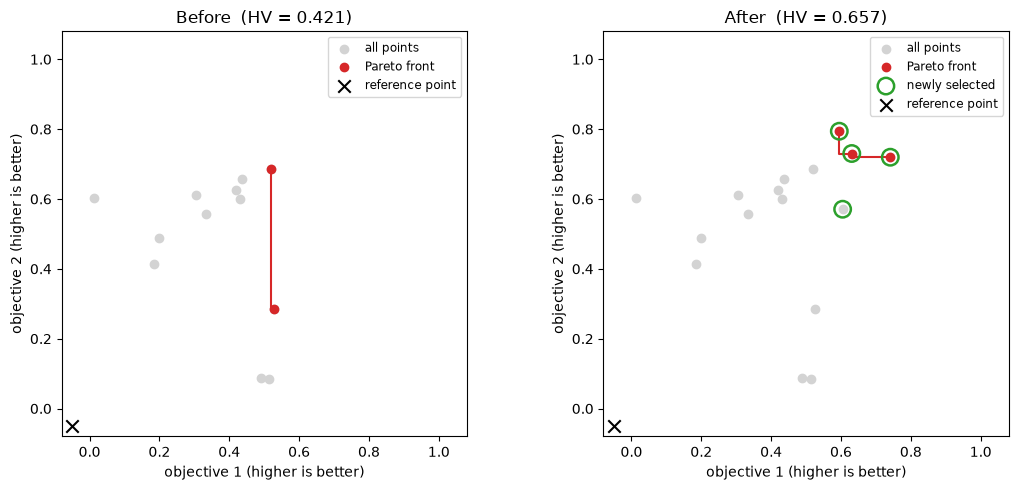

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
selected_after = torch.zeros(updated_Y.shape[0], dtype=torch.bool)
selected_after[train_Y.shape[0]:] = True

plotting.plot_pareto_front(
    train_Y, ref_point=REF_POINT, title=f"Before  (HV = {hv_before:.3f})", ax=axes[0]
)
plotting.plot_pareto_front(
    updated_Y,
    selected_mask=selected_after,
    ref_point=REF_POINT,
    title=f"After  (HV = {hv_after:.3f})",
    ax=axes[1],
)
fig.tight_layout();

## 01.13 — Acquisition syntax clinic

In the competition you will swap acquisition functions like cards. The point of
this cell: **all three flow through the exact same optimizer interface.** Build a
different acquisition, hand it to `optimize_discrete`, get a batch — nothing else
changes.

- `qLogNEHVI` — hypervolume improvement (what we used above),
- `qLogNParEGO` — random-weight scalarization (explores many trade-offs),
- a **fixed-weight** scalarization — commits to one preference.

In [14]:
from mobo_lab.acquisitions import build_fixed_scalarized_qlognei
from botorch.acquisition.multi_objective.parego import qLogNParEGO

clinic_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]), seed=SEED)

acq_parego = qLogNParEGO(
    model=model, X_baseline=train_X, sampler=clinic_sampler, prune_baseline=True
)
acq_scalarized = build_fixed_scalarized_qlognei(
    model, train_X, weights=torch.tensor([0.5, 0.5], dtype=torch.double), sampler=clinic_sampler
)

for name, acq in [("qLogNEHVI", acq_nehvi), ("qLogNParEGO", acq_parego),
                  ("scalarized_0.5_0.5", acq_scalarized)]:
    _c, ids = optimize_discrete(acq, pool, q=BATCH_SIZE, observed_ids=initial_ids)
    print(f"{name:<20} -> {ids}")

/Users/jiwonpark/stage/multi-objective-reasoning-lab/.venv/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


qLogNEHVI            -> [604, 581, 1172, 86]
qLogNParEGO          -> [1855, 1839, 1210, 1757]
scalarized_0.5_0.5   -> [1365, 1210, 1069, 1757]


## 01.14 — Shape-error cheat sheet

The most common errors in this lab are shape mismatches. Keep this handy:

| symptom | likely cause | fix |
|---|---|---|
| acquisition returns the wrong number of values | candidate tensor is `[q, d]`, not `[batch, q, d]` | add a batch dim: `X.unsqueeze(0)` |
| `train_Y` rejected by the model | shape `[n]` instead of `[n, 2]` | keep objectives 2-D: `Y.reshape(n, 2)` |
| hypervolume looks wrong / zero | objectives below the reference point, or ref point too high | use the fixed `REF_POINT` |
| "expected double, got float" | mixed dtypes | everything is `torch.double` (set by `set_all_seeds`) |
| projected batch has duplicates | forgot to pass `observed_ids` / `pending_ids` | pass them so chosen rows are excluded |

## 01.15 — Verify the golden path

Finally, check your round against the frozen reference. If this prints the success
message, your environment reproduces the golden path exactly and you are ready for
the strategy-card notebook.

In [15]:
verify_golden_path(candidate_ids, new_Y, hv_before, hv_after)

Golden-path check passed. You are ready for the strategy-card notebook.


## Takeaways

- One BO round is **fit → score → pick → measure → update**, and the hypervolume
  is how we keep score.
- **qLogNEHVI** picks a batch by expected hypervolume growth under noise.
- Picking from the **discrete pool** makes the result reproducible; the continuous
  optimizer is shown only for syntax.
- Swapping acquisition functions is a one-line change — the optimizer interface is
  the same for all of them. That is exactly what the competition will exploit.